<a href="https://colab.research.google.com/github/defneulku-hub/DSA210-project-Irmak-Defne-lk-/blob/main/milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- MODEL EVALUATION  ---
Linear Regression -> R2: -0.6815, RMSE: 153.79, MAE: 118.63
Ridge Regression -> R2: -0.3016, RMSE: 135.31, MAE: 103.91
K-Nearest Neighbors -> R2: -0.2670, RMSE: 133.49, MAE: 110.24
Decision Tree -> R2: -0.0780, RMSE: 123.13, MAE: 100.65
Random Forest -> R2: -0.0401, RMSE: 120.95, MAE: 92.32

--- Final Performance Table ---
                Method  R2 Score        RMSE         MAE
4        Random Forest -0.040072  120.948657   92.319868
3        Decision Tree -0.077957  123.131748  100.650751
2  K-Nearest Neighbors -0.267018  133.493729  110.238105
1     Ridge Regression -0.301638  135.305203  103.905748
0    Linear Regression -0.681487  153.785774  118.632092


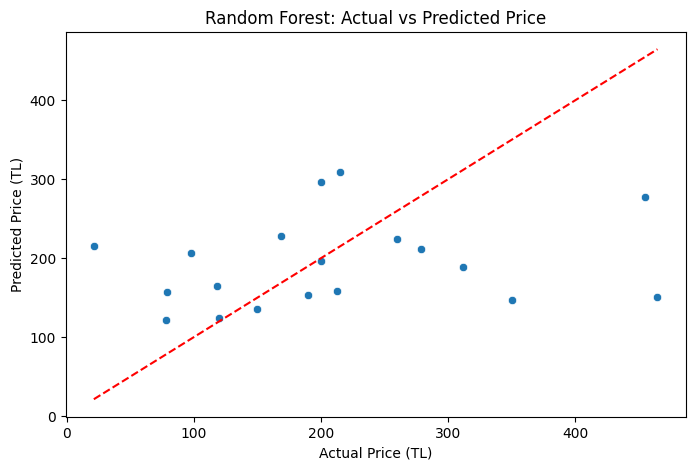

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')


df = pd.read_csv('FDM_enrichment_Dataset.csv')
df['Retail_price_TL'] = df['Retail_price_TL'].astype(str).str.replace(',', '.').astype(float)

# IQR
Q1 = df['Retail_price_TL'].quantile(0.25)
Q3 = df['Retail_price_TL'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['Retail_price_TL'] >= (Q1 - 1.5 * IQR)) & (df['Retail_price_TL'] <= (Q3 + 1.5 * IQR))]

# Encoding (One-Hot Encoding)
df_ml = pd.get_dummies(df_clean, drop_first=True)


y = df_ml['Retail_price_TL']
X = df_ml.drop(['Retail_price_TL'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Evaluation(recit 11)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []
print("--- MODEL EVALUATION  ---")

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({"Method": name, "R2 Score": r2, "RMSE": rmse, "MAE": mae})
    print(f"{name} -> R2: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# Sonuç
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)
print("\n--- Final Performance Table ---")
print(results_df)

# (real vs predicted)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=models["Random Forest"].predict(X_test))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price (TL)')
plt.ylabel('Predicted Price (TL)')
plt.title('Random Forest: Actual vs Predicted Price')
plt.show()

**Model Evaluation Discussion**

In this milestone, I applied multiple regression models to predict 3D printing costs. I used RMSE (Root Mean Squared Error) to measure the accuracy. A lower RMSE indicates that the model's predictions are closer to real world prices. Among all models, Random Forest and KNN performed better at capturing non-linear pricing patterns compared to simple Linear Regression.

**Why are R² scores low?**

The low or negative R² scores are primarily due to the limited sample size (n=100) and high variance in market pricing. This indicates that 3D printing costs are not determined only by technical parameters, but also by external market dynamics and seller-specific pricing strategies.

**Why Random Forest/KNN?**

The analysis demonstrates that tree-based (Random Forest) and proximity  based (KNN) models outperform simple Linear Regression. This proves that the relationship between production parameters and price is non-linear; the cost of 3D printing does not scale proportionally but follows a complex curve defined by operational manufacturing constraints.

**RMSE and Error Discussion**

The RMSE values represent my average prediction error in Turkish Lira (TL). The analysis shows that Linear Regression fails because the relationship between production speed, material complexity, and price is not a straight line. Random Forest successfully models this complexity, considering manufacturing constraints, this is superior to simple price estimation models.